# Utsunomiya LRT preliminary analysis + Sasaki/Sato-style CBA replication

This notebook is the shapefile-based version of the previous replication template.
It assumes that your processed or raw GIS layers are stored under `data/` as **ESRI Shapefile** layers, not GeoJSON.

It produces the same intended outputs as before:

- Preliminary GIS summaries: LRT catchment population, bus connectivity, land price by LRT distance, road density, optional hospital/clinic access.
- Sasaki/Sato-style logit relocation simulation using the parameters from the paper.
- Cost-benefit comparison tables and maps.
- PNG figures, CSV tables, and processed shapefiles.

## Expected shapefiles under `data/`

The notebook searches recursively, so files can be inside subfolders.
Recommended names:

```text
data/
  gadm41_JPN_1.shp
  gadm41_JPN_2.shp
  250m_mesh_2024_09.shp
  P11-22_09.shp
  RailroadSection2.shp
  Station2.shp
  L01-26_09.shp
  N13-24_5439.shp
  lrt_stops.shp
  feeder_stops.shp                 # optional
  tsunomiya_hospitals_clinics.shp            # optional
  utsunomiya_clinics.shp              # optional
  grocery_stores.shp                # optional
  flood_depth_by_mesh.shp           # optional
```

If your layer names are different, edit the `LAYER_PATTERNS` cell below.

In [1]:
# Imports and global settings
from pathlib import Path
import warnings
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

warnings.filterwarnings("ignore", category=UserWarning)

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
SHP_DIR = OUTPUT_DIR / "shapefiles"

for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, SHP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Coordinate systems
CRS_WGS84 = "EPSG:4326"
CRS_JGD2011_GEOG = "EPSG:6668"
CRS_ANALYSIS = "EPSG:6678"  # JGD2011 / Japan Plane Rectangular CS IX, meters

# Modeling assumptions
OPEN_YEAR = 2023
ANALYSIS_YEARS = 40
DISCOUNT_RATE = 0.04
AVG_HH_SIZE = 2.2
HOUSEHOLD_INCOME_YEN = 4_500_000  # Replace with municipal-taxation income if available.
LATEST_LRT_COST_MILLION_YEN = 68_400.0  # 684 oku yen, latest public project-cost assumption used in prior step.
FEEDER_EXTRA_COST_MILLION_YEN = 63_617.6 - 59_615.6  # same incremental feeder cost from paper, as default

# Travel assumptions used to approximate Sasaki/Sato variables when timetable data are not available.
WALK_SPEED_M_PER_MIN = 80.0
ROAD_DISTANCE_FACTOR = 1.1666
LRT_END_TO_END_MIN = 44.0       # edit if you use official timetable by stop
PT_FALLBACK_SPEED_M_PER_MIN = 500.0
DEFAULT_GROCERY_WALK_MIN = 10.0
DEFAULT_FLOOD_DEPTH_M = 0.0

print("Output folders:")
print(" -", FIG_DIR)
print(" -", TABLE_DIR)
print(" -", SHP_DIR)

Output folders:
 - outputs/figures
 - outputs/tables
 - outputs/shapefiles


## 1. Shapefile discovery and robust loading

This version reads `.shp` layers directly. It first tries the recommended filenames, then recursive wildcard patterns.

In [3]:
# Edit these if your filenames differ.
LAYER_PATTERNS = {
    "adm1": ["gadm41_JPN_1.shp", "*JPN*1*.shp", "*adm*1*.shp"],
    "adm2": ["gadm41_JPN_2.shp", "*JPN*2*.shp", "*adm*2*.shp"],
    "pop_mesh": ["250m_mesh_2024_09.shp", "*250m*mesh*.shp", "*mesh*2024*.shp", "*population*mesh*.shp"],
    "bus_stops": ["P11-22_09.shp", "P11*.shp", "*bus*stop*.shp", "*bus*.shp"],
    "rail_lines": ["RailroadSection2.shp", "*RailroadSection*.shp", "*rail*line*.shp"],
    "rail_stations": ["Station2.shp", "*Station*.shp", "*rail*station*.shp"],
    "land_price": ["L01-26_09.shp", "L01*.shp", "*land*price*.shp", "*地価*.shp"],
    "roads": ["N13-24_5439.shp", "N13*.shp", "*road*.shp", "*道路*.shp"],
    "lrt_stops": ["lrt_stops.shp", "*lrt*stop*.shp", "*lightline*stop*.shp", "*ライトライン*停*.shp"],
    "feeder_stops": ["feeder_stops.shp", "*feeder*stop*.shp", "*fbs*stop*.shp"],
    "hospitals": ["utsunomiya_hospitals_clinics.shp", "*hospital*.shp", "*byouin*.shp", "*病院*.shp"],
    "clinics": ["utsunomiya_clinics.shp", "*clinic*.shp", "*sinryojo*.shp", "*診療*.shp"],
    "grocery": ["grocery_stores.shp", "*grocery*.shp", "*supermarket*.shp", "*スーパー*.shp"],
    "flood": ["flood_depth_by_mesh.shp", "*flood*.shp", "*hazard*.shp", "*洪水*.shp"],
}

def find_layer(key, required=False):
    patterns = LAYER_PATTERNS[key]
    matches = []
    for pat in patterns:
        matches.extend(sorted(DATA_DIR.rglob(pat)))
    # Deduplicate while preserving order
    seen = set()
    unique = []
    for m in matches:
        if m.resolve() not in seen:
            seen.add(m.resolve())
            unique.append(m)
    if unique:
        print(f"{key:15s} -> {unique[0]}")
        return unique[0]
    if required:
        raise FileNotFoundError(f"Required layer '{key}' not found under {DATA_DIR}. Patterns: {patterns}")
    print(f"{key:15s} -> not found, skipped")
    return None

layer_paths = {k: find_layer(k, required=k in ["pop_mesh", "lrt_stops"]) for k in LAYER_PATTERNS}

adm1            -> data/gadm41_JPN_1.shp
adm2            -> data/gadm41_JPN_2.shp
pop_mesh        -> data/250m_mesh_2024_09.shp
bus_stops       -> data/P11-22_09.shp
rail_lines      -> data/N05-25_RailroadSection2.shp
rail_stations   -> data/N05-25_Station2.shp
land_price      -> data/L01-26_09.shp
roads           -> data/N13-24_5439.shp
lrt_stops       -> data/lrt_stops.shp
feeder_stops    -> not found, skipped
hospitals       -> data/utsunomiya_hospitals_clinics.shp
clinics         -> data/utsunomiya_clinics.shp
grocery         -> not found, skipped
flood           -> not found, skipped


In [4]:
def read_shp(path, target_crs=CRS_ANALYSIS, default_crs=None, encoding_candidates=("utf-8", "cp932", "shift_jis")):
    """Read a shapefile with fallback encodings and normalize CRS."""
    if path is None:
        return None
    last_err = None
    for enc in encoding_candidates:
        try:
            gdf = gpd.read_file(path, encoding=enc)
            break
        except Exception as e:
            last_err = e
    else:
        raise last_err
    if gdf.crs is None:
        if default_crs is None:
            print(f"WARNING: {path.name} has no CRS. Assuming {CRS_JGD2011_GEOG}.")
            default_crs = CRS_JGD2011_GEOG
        gdf = gdf.set_crs(default_crs, allow_override=True)
    if target_crs is not None:
        gdf = gdf.to_crs(target_crs)
    # Remove empty geometries
    gdf = gdf[~gdf.geometry.isna()].copy()
    return gdf

adm1 = read_shp(layer_paths["adm1"], default_crs=CRS_WGS84) if layer_paths["adm1"] else None
adm2 = read_shp(layer_paths["adm2"], default_crs=CRS_WGS84) if layer_paths["adm2"] else None
pop_raw = read_shp(layer_paths["pop_mesh"], default_crs=CRS_JGD2011_GEOG)
bus_raw = read_shp(layer_paths["bus_stops"], default_crs=CRS_JGD2011_GEOG) if layer_paths["bus_stops"] else None
rail_lines_raw = read_shp(layer_paths["rail_lines"], default_crs=CRS_JGD2011_GEOG) if layer_paths["rail_lines"] else None
rail_stations_raw = read_shp(layer_paths["rail_stations"], default_crs=CRS_JGD2011_GEOG) if layer_paths["rail_stations"] else None
land_raw = read_shp(layer_paths["land_price"], default_crs=CRS_JGD2011_GEOG) if layer_paths["land_price"] else None
roads_raw = read_shp(layer_paths["roads"], default_crs=CRS_JGD2011_GEOG) if layer_paths["roads"] else None
lrt_stops_raw = read_shp(layer_paths["lrt_stops"], default_crs=CRS_JGD2011_GEOG)
feeder_stops_raw = read_shp(layer_paths["feeder_stops"], default_crs=CRS_JGD2011_GEOG) if layer_paths["feeder_stops"] else None
hospitals_raw = read_shp(layer_paths["hospitals"], default_crs=CRS_JGD2011_GEOG) if layer_paths["hospitals"] else None
clinics_raw = read_shp(layer_paths["clinics"], default_crs=CRS_JGD2011_GEOG) if layer_paths["clinics"] else None
grocery_raw = read_shp(layer_paths["grocery"], default_crs=CRS_JGD2011_GEOG) if layer_paths["grocery"] else None
flood_raw = read_shp(layer_paths["flood"], default_crs=CRS_JGD2011_GEOG) if layer_paths["flood"] else None

for name, gdf in {
    "pop_raw": pop_raw, "bus_raw": bus_raw, "rail_lines_raw": rail_lines_raw,
    "rail_stations_raw": rail_stations_raw, "land_raw": land_raw, "roads_raw": roads_raw,
    "lrt_stops_raw": lrt_stops_raw, "hospitals_raw": hospitals_raw, "clinics_raw": clinics_raw
}.items():
    if gdf is not None:
        print(f"{name:18s}: {len(gdf):>6,d} features, geometry={gdf.geom_type.mode().iloc[0] if len(gdf) else 'NA'}")

pop_raw           : 34,921 features, geometry=Polygon
bus_raw           :  3,778 features, geometry=Point
rail_lines_raw    :  2,653 features, geometry=LineString
rail_stations_raw : 23,864 features, geometry=Point
land_raw          :    458 features, geometry=Point
roads_raw         : 1,267,863 features, geometry=LineString
lrt_stops_raw     :     34 features, geometry=Point
hospitals_raw     :    470 features, geometry=Point
clinics_raw       :    437 features, geometry=Point


## 2. Study-area boundary and clipping

The main study area is Utsunomiya + Haga because the LRT route extends from Utsunomiya Station East Exit toward Haga-Takanezawa Industrial Park. If administrative boundaries are unavailable, the notebook uses a broad LRT corridor buffer as fallback.

In [5]:
def contains_any(series, keywords):
    s = series.astype(str).fillna("")
    mask = False
    for kw in keywords:
        mask = mask | s.str.contains(kw, case=False, regex=False, na=False)
    return mask

def select_boundary(adm2, lrt_stops, buffer_m=3000):
    if adm2 is not None:
        name_cols = [c for c in ["NAME_2", "NL_NAME_2", "VARNAME_2", "NAME_1", "NL_NAME_1"] if c in adm2.columns]
        mask = pd.Series(False, index=adm2.index)
        for c in name_cols:
            mask = mask | contains_any(adm2[c], ["Utsunomiya", "宇都宮", "Haga", "芳賀"])
        if mask.any():
            return adm2.loc[mask].copy()
    # Fallback: LRT corridor + around population extent
    print("Administrative study boundary not found; using LRT 3 km corridor fallback.")
    geom = lrt_stops.geometry.union_all().buffer(buffer_m)
    return gpd.GeoDataFrame({"name": ["lrt_corridor_fallback"]}, geometry=[geom], crs=CRS_ANALYSIS)

study_area = select_boundary(adm2, lrt_stops_raw)
study_union = study_area.geometry.union_all()

# Tochigi boundary for broader map, if available
tochigi = None
if adm1 is not None:
    name_cols = [c for c in ["NAME_1", "NL_NAME_1", "VARNAME_1"] if c in adm1.columns]
    mask = pd.Series(False, index=adm1.index)
    for c in name_cols:
        mask = mask | contains_any(adm1[c], ["Tochigi", "栃木"])
    if mask.any():
        tochigi = adm1.loc[mask].copy()

def clip_to_study(gdf):
    if gdf is None:
        return None
    try:
        return gpd.clip(gdf, study_area)
    except Exception:
        return gdf[gdf.intersects(study_union)].copy()

pop = clip_to_study(pop_raw)
bus = clip_to_study(bus_raw)
rail_lines = clip_to_study(rail_lines_raw)
rail_stations = clip_to_study(rail_stations_raw)
land = clip_to_study(land_raw)
roads = clip_to_study(roads_raw)
lrt_stops = clip_to_study(lrt_stops_raw)
feeder_stops = clip_to_study(feeder_stops_raw)
hospitals = clip_to_study(hospitals_raw)
clinics = clip_to_study(clinics_raw)
grocery = clip_to_study(grocery_raw)
flood = clip_to_study(flood_raw)

print("Clipped study layers:")
for name, gdf in {"pop": pop, "bus": bus, "rail_stations": rail_stations, "land": land, "roads": roads, "lrt_stops": lrt_stops, "hospitals": hospitals, "clinics": clinics}.items():
    if gdf is not None:
        print(f"{name:15s}: {len(gdf):>6,d}")

Clipped study layers:
pop            :  5,061
bus            :    887
rail_stations  :     34
land           :    120
roads          : 74,629
lrt_stops      :     34
hospitals      :    470
clinics        :    437


## 3. Helper functions for fields, distances, shapefile export, and plots

In [6]:
def first_existing_col(gdf, candidates):
    if gdf is None:
        return None
    cols_lower = {c.lower(): c for c in gdf.columns}
    for c in candidates:
        if c in gdf.columns:
            return c
        if c.lower() in cols_lower:
            return cols_lower[c.lower()]
    return None

POP_TOTAL_COL = first_existing_col(pop, ["PT00_2025", "PTN_2025", "PTN_2020", "PT00_2020", "population", "pop"])
POP_ELDER_COL = first_existing_col(pop, ["PTC_2025", "PTC_2020", "elderly", "pop65"])
BUS_NAME_COL = first_existing_col(bus, ["P11_001", "stop_name", "name"])
BUS_OPERATOR_COL = first_existing_col(bus, ["P11_002", "operator", "agency"])
LAND_PRICE_COL = first_existing_col(land, ["L01_008", "price", "landprice"])
LAND_YOY_COL = first_existing_col(land, ["L01_009", "yoy", "change"])
LAND_USE_COL = first_existing_col(land, ["L01_002", "use", "用途"])
STATION_NAME_COL = first_existing_col(rail_stations, ["N05_011", "S12_001", "station", "name"])
LRT_NAME_COL = first_existing_col(lrt_stops, ["stop_name", "name", "N05_011", "S12_001"])

required_cols = {"population total": POP_TOTAL_COL, "LRT stop name": LRT_NAME_COL}
print("Detected columns:")
for label, col in {**required_cols, "elderly": POP_ELDER_COL, "bus name": BUS_NAME_COL, "bus operator": BUS_OPERATOR_COL, "land price": LAND_PRICE_COL, "land YoY": LAND_YOY_COL}.items():
    print(f"{label:20s}: {col}")

if POP_TOTAL_COL is None:
    raise ValueError("Could not detect total population column. Edit POP_TOTAL_COL manually.")
if LRT_NAME_COL is None:
    lrt_stops["stop_name"] = [f"LRT_{i+1:02d}" for i in range(len(lrt_stops))]
    LRT_NAME_COL = "stop_name"

def safe_log(x, floor=1e-6):
    return np.log(np.maximum(np.asarray(x, dtype=float), floor))

def nearest_distance_m(left_gdf, right_gdf):
    if left_gdf is None or right_gdf is None or len(right_gdf) == 0:
        return pd.Series(np.nan, index=left_gdf.index)
    # Use sjoin_nearest if available.
    try:
        j = gpd.sjoin_nearest(left_gdf[["geometry"]].copy(), right_gdf[["geometry"]].copy(), how="left", distance_col="dist")
        return j.groupby(level=0)["dist"].min().reindex(left_gdf.index)
    except Exception:
        geom_union = right_gdf.geometry.union_all()
        return left_gdf.geometry.distance(geom_union)

def standardize_point_layer(gdf):
    if gdf is None:
        return None
    out = gdf.copy()
    # convert non-points to centroids for station/hospital layers if needed
    if not out.geom_type.isin(["Point", "MultiPoint"]).all():
        out["geometry"] = out.geometry.centroid
    return out

def short_columns_for_shp(gdf):
    """Return a copy with shapefile-safe column names <= 10 chars."""
    g = gdf.copy()
    new_cols = []
    used = set()
    for c in g.columns:
        if c == g.geometry.name:
            new_cols.append(c)
            continue
        base = ''.join(ch if ch.isalnum() or ch == '_' else '_' for ch in str(c))[:10]
        if not base:
            base = "field"
        name = base
        i = 1
        while name.lower() in used:
            suffix = str(i)
            name = base[:10-len(suffix)] + suffix
            i += 1
        used.add(name.lower())
        new_cols.append(name)
    g.columns = new_cols
    # Convert unsupported columns to strings/numeric where needed
    for c in g.columns:
        if c == g.geometry.name:
            continue
        if pd.api.types.is_datetime64_any_dtype(g[c]):
            g[c] = g[c].astype(str)
        elif g[c].dtype == "object":
            g[c] = g[c].astype(str).str.slice(0, 254)
    return g

def export_shp(gdf, filename):
    if gdf is None or len(gdf) == 0:
        print(f"Skipping empty layer: {filename}")
        return None
    path = SHP_DIR / filename
    g = short_columns_for_shp(gdf)
    g.to_file(path, driver="ESRI Shapefile", encoding="utf-8")
    print("Wrote", path)
    return path

def plot_base(ax):
    study_area.boundary.plot(ax=ax, linewidth=1)
    if roads is not None and len(roads):
        roads.plot(ax=ax, linewidth=0.2, alpha=0.35)
    if rail_lines is not None and len(rail_lines):
        rail_lines.plot(ax=ax, linewidth=1.0, alpha=0.75)

Detected columns:
population total    : PT00_2025
LRT stop name       : stop_name
elderly             : PTC_2025
bus name            : P11_001
bus operator        : P11_002
land price          : L01_008
land YoY            : L01_009


## 4. Preliminary analysis A: LRT buffers and population catchments

This creates 500m and 800m LRT walking catchments and summarizes total population and elderly population in each station buffer.

In [7]:
# Normalize important layers to points
lrt_stops = standardize_point_layer(lrt_stops)
bus = standardize_point_layer(bus)
rail_stations = standardize_point_layer(rail_stations)
hospitals = standardize_point_layer(hospitals)
clinics = standardize_point_layer(clinics)
grocery = standardize_point_layer(grocery)

# LRT buffers
lrt_500 = lrt_stops[[LRT_NAME_COL, "geometry"]].copy()
lrt_500["geometry"] = lrt_500.geometry.buffer(500)
lrt_500 = lrt_500.rename(columns={LRT_NAME_COL: "lrt_stop"})
lrt_500["buf_m"] = 500

lrt_800 = lrt_stops[[LRT_NAME_COL, "geometry"]].copy()
lrt_800["geometry"] = lrt_800.geometry.buffer(800)
lrt_800 = lrt_800.rename(columns={LRT_NAME_COL: "lrt_stop"})
lrt_800["buf_m"] = 800

# Clean population columns
pop = pop.copy()
pop[POP_TOTAL_COL] = pd.to_numeric(pop[POP_TOTAL_COL], errors="coerce").fillna(0)
if POP_ELDER_COL:
    pop[POP_ELDER_COL] = pd.to_numeric(pop[POP_ELDER_COL], errors="coerce").fillna(0)
else:
    pop["elderly_est"] = 0.0
    POP_ELDER_COL = "elderly_est"

# Intersect population mesh with buffers. For partial mesh overlaps, area-weight population.
pop["orig_area"] = pop.geometry.area
pop_light = pop[[POP_TOTAL_COL, POP_ELDER_COL, "orig_area", "geometry"]].copy()

def area_weighted_summary(buffer_gdf, label):
    inter = gpd.overlay(pop_light, buffer_gdf, how="intersection")
    if len(inter) == 0:
        return pd.DataFrame(columns=["lrt_stop", "buf_m", "pop_total", "pop65", "n_mesh"])
    inter["area_w"] = inter.geometry.area / inter["orig_area"].replace({0: np.nan})
    inter["pop_w"] = inter[POP_TOTAL_COL] * inter["area_w"]
    inter["pop65_w"] = inter[POP_ELDER_COL] * inter["area_w"]
    s = inter.groupby("lrt_stop").agg(
        pop_total=("pop_w", "sum"),
        pop65=("pop65_w", "sum"),
        n_mesh=("pop_w", "size")
    ).reset_index()
    s["buf_m"] = label
    s["elderly_share"] = s["pop65"] / s["pop_total"].replace({0: np.nan})
    return s

pop_summary_500 = area_weighted_summary(lrt_500, 500)
pop_summary_800 = area_weighted_summary(lrt_800, 800)
pop_catchment_summary = pd.concat([pop_summary_500, pop_summary_800], ignore_index=True)
pop_catchment_summary.to_csv(TABLE_DIR / "lrt_population_catchment_summary.csv", index=False)

display(pop_catchment_summary.head(20))

,lrt_stop,pop_total,pop65,n_mesh,buf_m,elderly_share
0,かしの森公園前,58.435720,21.837959,6,500,0.373709
1,ゆいの杜中央,6488.126084,628.926195,43,500,0.096935
2,ゆいの杜東,4916.788483,425.970364,31,500,0.086636
3,ゆいの杜西,4775.207444,725.330025,41,500,0.151895
4,グリーンスタジアム前,18.593480,5.808496,8,500,0.312394
5,宇都宮大学陽東キャンパス,7077.938460,1403.570319,38,500,0.198302
6,宇都宮駅東口,4118.829613,956.485142,20,500,0.232223
7,峰,10075.859370,2177.431196,40,500,0.216104
8,平石,1040.835967,337.672199,32,500,0.324424
9,平石中央小学校前,882.855852,270.240120,34,500,0.306098


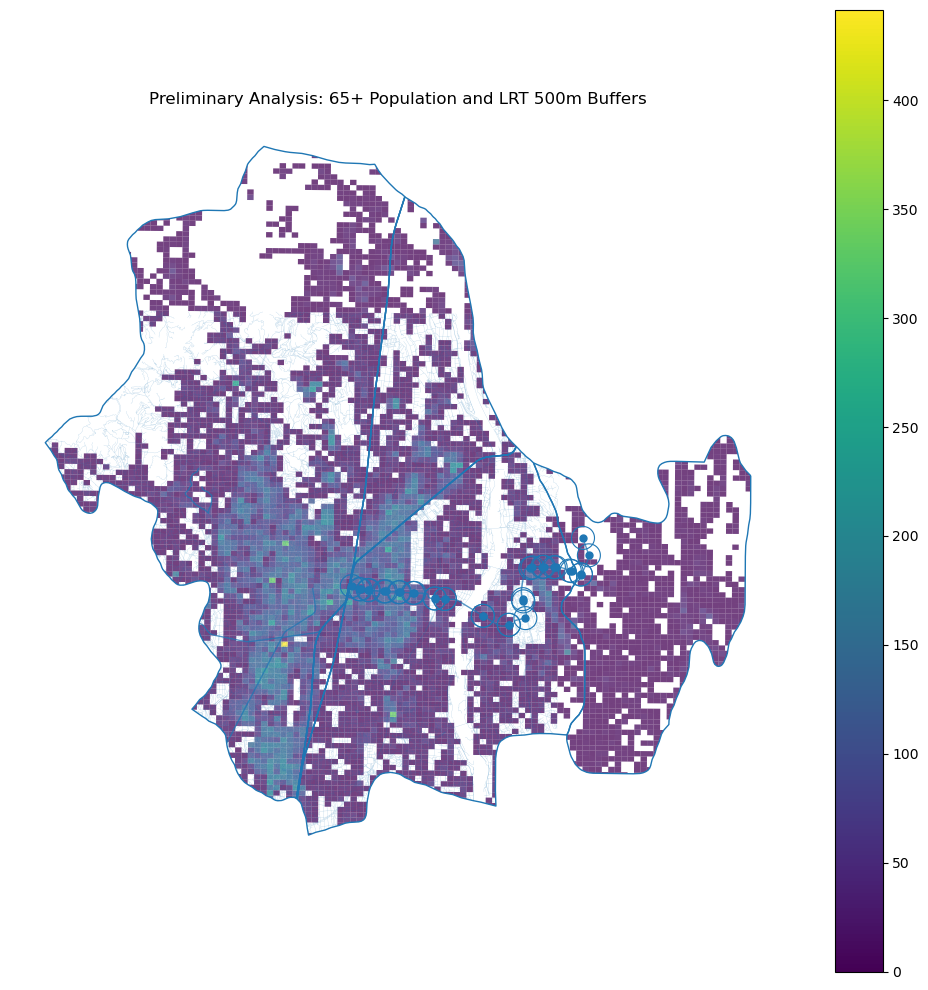

In [8]:
# Map: elderly population and LRT catchments
fig, ax = plt.subplots(figsize=(10, 10))
plot_base(ax)
pop.plot(ax=ax, column=POP_ELDER_COL, legend=True, edgecolor="none", alpha=0.75)
lrt_500.boundary.plot(ax=ax, linewidth=0.8)
lrt_stops.plot(ax=ax, markersize=25)
ax.set_title("Preliminary Analysis: 65+ Population and LRT 500m Buffers")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG_DIR / "map_elderly_population_lrt_500m.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Preliminary analysis B: Bus, railway, and optional hospital/clinic connectivity

This block calculates how many bus stops, railway stations, hospitals, and clinics are within 500m of each LRT stop.

In [9]:
def count_points_within_buffers(points_gdf, buffer_gdf, label, name_col=None):
    if points_gdf is None or len(points_gdf) == 0:
        return pd.DataFrame({"lrt_stop": buffer_gdf["lrt_stop"], label: 0})
    j = gpd.sjoin(points_gdf[[c for c in points_gdf.columns if c != "geometry"] + ["geometry"]],
                  buffer_gdf[["lrt_stop", "geometry"]], how="inner", predicate="within")
    if len(j) == 0:
        return pd.DataFrame({"lrt_stop": buffer_gdf["lrt_stop"], label: 0})
    if name_col and name_col in j.columns:
        s = j.groupby("lrt_stop")[name_col].nunique().rename(label).reset_index()
    else:
        s = j.groupby("lrt_stop").size().rename(label).reset_index()
    return buffer_gdf[["lrt_stop"]].merge(s, on="lrt_stop", how="left").fillna({label: 0})

bus_counts = count_points_within_buffers(bus, lrt_500, "bus_stops_500m", BUS_NAME_COL)
rail_counts = count_points_within_buffers(rail_stations, lrt_500, "rail_stations_500m", STATION_NAME_COL)
hosp_counts = count_points_within_buffers(hospitals, lrt_500, "hospitals_500m")
clinic_counts = count_points_within_buffers(clinics, lrt_500, "clinics_500m")

connectivity = bus_counts.merge(rail_counts, on="lrt_stop", how="outer")\
                         .merge(hosp_counts, on="lrt_stop", how="outer")\
                         .merge(clinic_counts, on="lrt_stop", how="outer")\
                         .fillna(0)

if bus is not None and BUS_OPERATOR_COL:
    j = gpd.sjoin(bus, lrt_500[["lrt_stop", "geometry"]], how="inner", predicate="within")
    op = j.groupby("lrt_stop")[BUS_OPERATOR_COL].nunique().rename("bus_ops_500m").reset_index() if len(j) else pd.DataFrame(columns=["lrt_stop", "bus_ops_500m"])
    connectivity = connectivity.merge(op, on="lrt_stop", how="left").fillna({"bus_ops_500m": 0})

connectivity.to_csv(TABLE_DIR / "lrt_bus_rail_hospital_connectivity_summary.csv", index=False)
display(connectivity)

,lrt_stop,bus_stops_500m,rail_stations_500m,hospitals_500m,clinics_500m,bus_ops_500m
0,飛山城跡,0.0,1,6.0,6.0,0.0
1,飛山城跡,0.0,1,6.0,6.0,0.0
2,飛山城跡,0.0,1,6.0,6.0,0.0
3,飛山城跡,0.0,1,6.0,6.0,0.0
4,飛山城跡,0.0,1,6.0,6.0,0.0
...,...,...,...,...,...,...
239,ゆいの杜中央,5.0,2,4.0,4.0,2.0
240,ゆいの杜中央,5.0,2,4.0,4.0,2.0
241,ゆいの杜中央,5.0,2,4.0,4.0,2.0
242,かしの森公園前,0.0,1,0.0,0.0,0.0


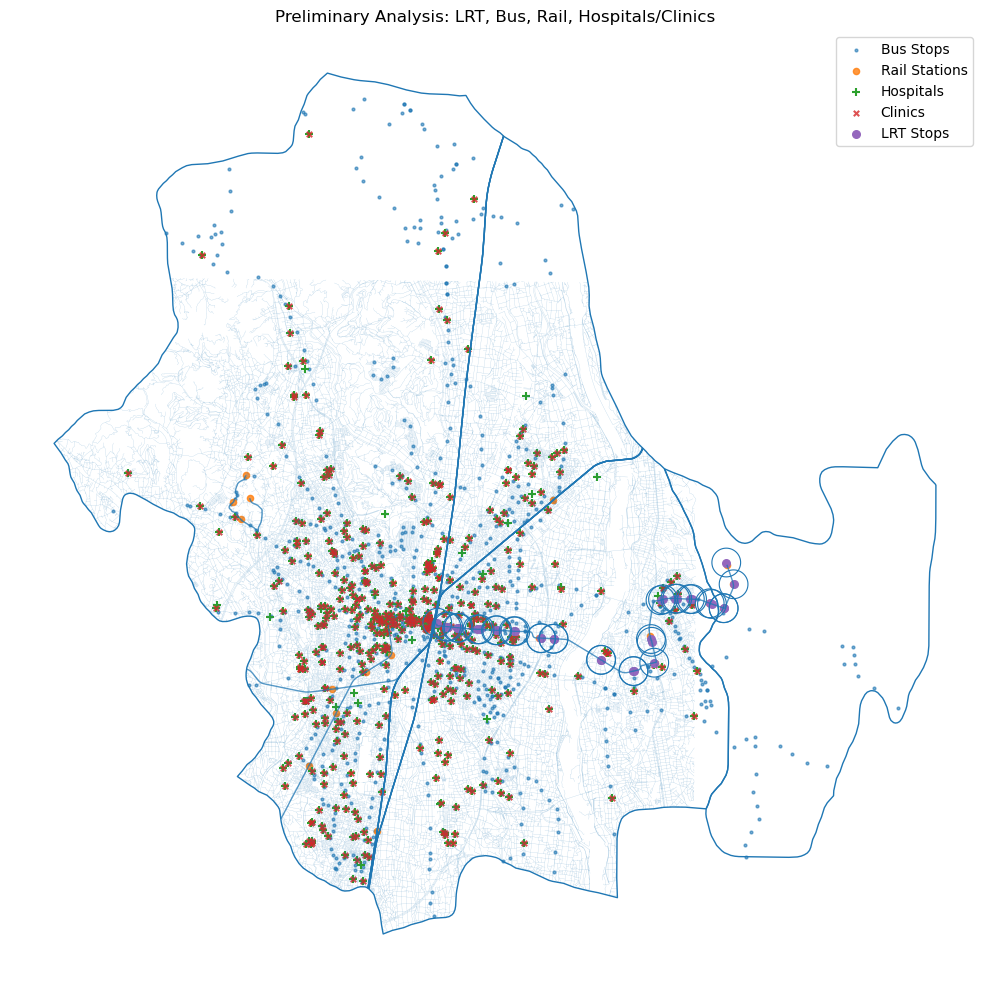

In [12]:
# Map: transit + optional hospitals / clinics
fig, ax = plt.subplots(figsize=(10, 10))
plot_base(ax)
lrt_500.boundary.plot(ax=ax, linewidth=0.8)
if bus is not None and len(bus):
    bus.plot(ax=ax, markersize=4, alpha=0.6, label = 'Bus Stops')
if rail_stations is not None and len(rail_stations):
    rail_stations.plot(ax=ax, markersize=20, alpha=0.8, label = 'Rail Stations')
if hospitals is not None and len(hospitals):
    hospitals.plot(ax=ax, markersize=35, marker="+", label = 'Hospitals')
if clinics is not None and len(clinics):
    clinics.plot(ax=ax, markersize=15, marker="x", alpha=0.8, label = 'Clinics')
lrt_stops.plot(ax=ax, markersize=30, label = 'LRT Stops')
ax.set_title("Preliminary Analysis: LRT, Bus, Rail, Hospitals/Clinics")
ax.set_axis_off()
plt.tight_layout()
plt.legend()
plt.savefig(FIG_DIR / "map_transit_hospital_connectivity.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Preliminary analysis C: Land price and road density

This block classifies land-price points by distance to the nearest LRT stop and summarizes land price / year-on-year change. It also calculates road density inside the study area.

In [13]:
# Land price by LRT distance zone
land_summary = pd.DataFrame()
if land is not None and len(land) and LAND_PRICE_COL:
    land = land.copy()
    land[LAND_PRICE_COL] = pd.to_numeric(land[LAND_PRICE_COL], errors="coerce")
    if LAND_YOY_COL:
        land[LAND_YOY_COL] = pd.to_numeric(land[LAND_YOY_COL], errors="coerce")
    lrt_union = lrt_stops.geometry.union_all()
    land["dist_lrt_m"] = land.geometry.distance(lrt_union)
    land["lrt_zone"] = pd.cut(
        land["dist_lrt_m"],
        bins=[0, 500, 1000, 2000, np.inf],
        labels=["0-500m", "500-1000m", "1000-2000m", "2000m+"]
    )
    agg_dict = {
        "n": (LAND_PRICE_COL, "count"),
        "mean_price": (LAND_PRICE_COL, "mean"),
        "median_price": (LAND_PRICE_COL, "median"),
    }
    if LAND_YOY_COL:
        agg_dict["mean_yoy"] = (LAND_YOY_COL, "mean")
    land_summary = land.groupby("lrt_zone", observed=True).agg(**agg_dict).reset_index()
    land_summary.to_csv(TABLE_DIR / "lrt_land_price_summary.csv", index=False)
    display(land_summary)
else:
    print("Land price layer or price column not found; skipping land-price summary.")

# Road density
road_summary = pd.DataFrame()
if roads is not None and len(roads):
    roads = roads.copy()
    roads["length_m"] = roads.geometry.length
    area_km2 = study_area.geometry.area.sum() / 1_000_000
    road_summary = pd.DataFrame({
        "study_area_km2": [area_km2],
        "road_length_km": [roads["length_m"].sum() / 1000],
        "road_density_km_per_km2": [(roads["length_m"].sum() / 1000) / area_km2]
    })
    road_summary.to_csv(TABLE_DIR / "road_density_summary.csv", index=False)
    display(road_summary)
else:
    print("Road layer not found; skipping road-density summary.")

,lrt_zone,n,mean_price,median_price,mean_yoy
0,0-500m,14,166692.857143,111000.0,3.178571
1,500-1000m,8,112587.500000,117500.0,2.012500
2,1000-2000m,25,115404.000000,106000.0,1.540000
3,2000m+,73,56836.986301,59200.0,0.569863


,study_area_km2,road_length_km,road_density_km_per_km2
0,499.182157,5721.034123,11.460815


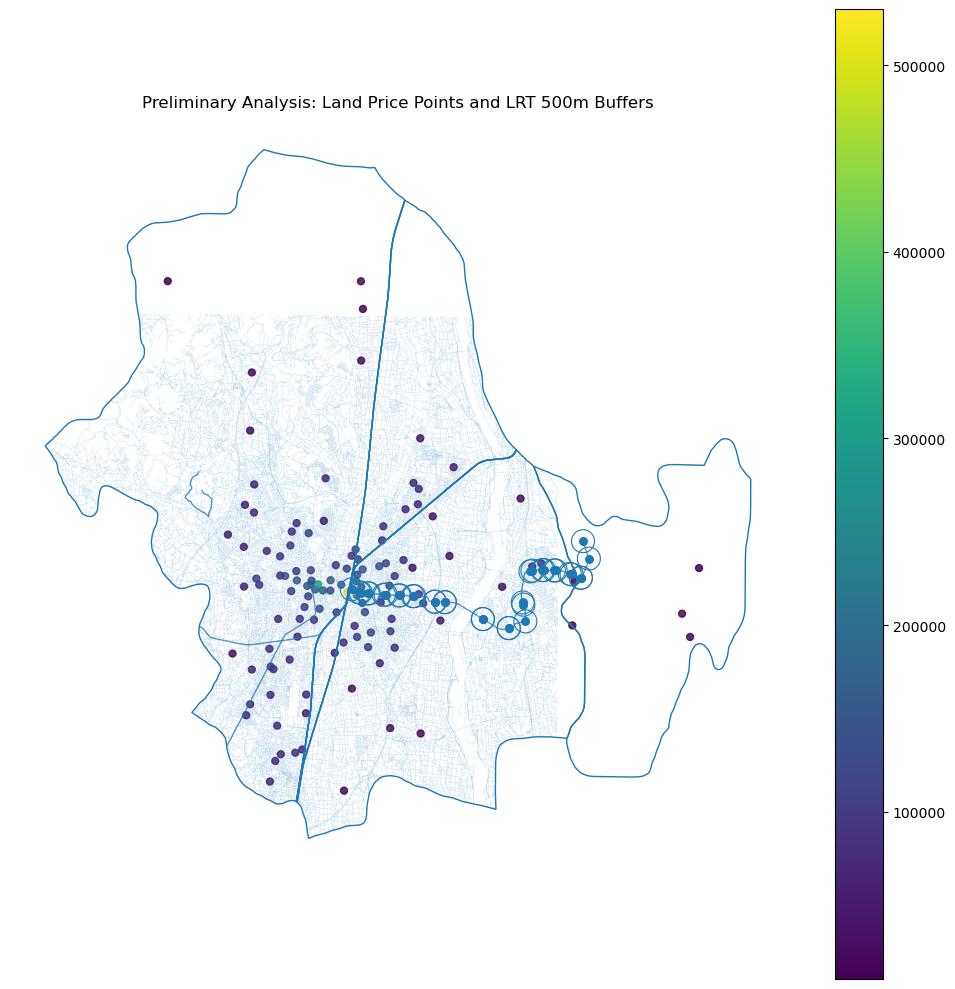

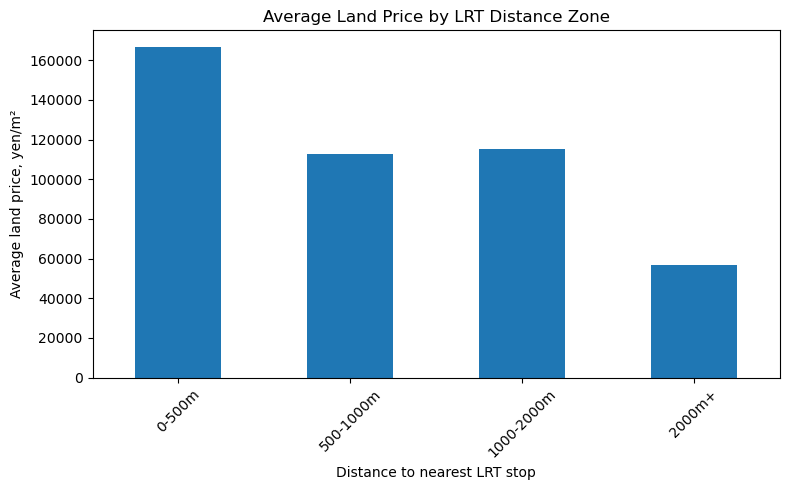

In [14]:
# Land price map and bar chart
if land is not None and len(land) and "dist_lrt_m" in land.columns:
    fig, ax = plt.subplots(figsize=(10, 10))
    plot_base(ax)
    land.plot(ax=ax, column=LAND_PRICE_COL, legend=True, markersize=25, alpha=0.85)
    lrt_500.boundary.plot(ax=ax, linewidth=0.8)
    lrt_stops.plot(ax=ax, markersize=30)
    ax.set_title("Preliminary Analysis: Land Price Points and LRT 500m Buffers")
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "map_land_price_lrt_distance.png", dpi=300, bbox_inches="tight")
    plt.show()

    if len(land_summary):
        fig, ax = plt.subplots(figsize=(8, 5))
        land_summary.plot(x="lrt_zone", y="mean_price", kind="bar", legend=False, ax=ax)
        ax.set_title("Average Land Price by LRT Distance Zone")
        ax.set_xlabel("Distance to nearest LRT stop")
        ax.set_ylabel("Average land price, yen/m²")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(FIG_DIR / "chart_land_price_by_lrt_zone.png", dpi=300, bbox_inches="tight")
        plt.show()

## 7. Export preliminary processed layers as shapefiles

Shapefile field names are limited to 10 characters, so exported column names may be shortened. CSV tables preserve the clearer long names.

In [15]:
export_shp(study_area, "study_area.shp")
export_shp(pop, "processed_population_mesh.shp")
export_shp(lrt_stops, "processed_lrt_stops.shp")
export_shp(lrt_500, "lrt_500m_buffers.shp")
export_shp(lrt_800, "lrt_800m_buffers.shp")
export_shp(bus, "processed_bus_stops.shp")
export_shp(rail_lines, "processed_rail_lines.shp")
export_shp(rail_stations, "processed_rail_stations.shp")
export_shp(land, "processed_land_price.shp")
export_shp(roads, "processed_roads.shp")
export_shp(hospitals, "processed_hospitals.shp")
export_shp(clinics, "processed_clinics.shp")

Wrote outputs/shapefiles/study_area.shp


/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Creating a 256th field, but some DBF readers might only support 255 fields
  ogr_write(


Wrote outputs/shapefiles/processed_population_mesh.shp
Wrote outputs/shapefiles/processed_lrt_stops.shp
Wrote outputs/shapefiles/lrt_500m_buffers.shp
Wrote outputs/shapefiles/lrt_800m_buffers.shp


/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '宇都宮～瑞穂野団地,駒生～卸会館前,駒生～健康の森～瑞穂野団地,駒生～瑞穂野団地［駅経由］,駒生～東汗,駒生～本郷台西汗,駒生～緑の郷～瑞穂野団地,瑞穂野団地～駒生［森経由］,本郷台西汗～健康の森～駒生' of field P11_003_01 has been truncated to 254 characters.  This warning will not be emitted any more for that layer.
  ogr_write(


Wrote outputs/shapefiles/processed_bus_stops.shp
Wrote outputs/shapefiles/processed_rail_lines.shp
Wrote outputs/shapefiles/processed_rail_stations.shp
Wrote outputs/shapefiles/processed_land_price.shp
Wrote outputs/shapefiles/processed_roads.shp
Wrote outputs/shapefiles/processed_hospitals.shp
Wrote outputs/shapefiles/processed_clinics.shp


PosixPath('outputs/shapefiles/processed_clinics.shp')

## 8. Sasaki/Sato-style logit model parameters

The utility model follows the article structure:

\[
V_{ik}=a\ln(ZA)+b\ln(ZB)+c\ln(ZC)+d\ln(ZD)+e\ln(r)
\]

where `ZA` is access time from home to the nearest railway/LRT/bus stop, `ZB` is public transport time to JR Utsunomiya, `ZC` is grocery access time, `ZD` is flood depth, and `r` is land price/rent proxy.

The paper's `ZD = 0` case is not directly compatible with a log transform, so this implementation uses `log(1 + flood_depth_m)` for the flood term.

In [16]:
PARAMS = {
    ("owned_detached", "20_30"): dict(a=-0.164, b=-0.628, c=-1.250, d=-1.581, e=-1.469, h=0.291),
    ("owned_detached", "40_50"): dict(a= 0.000, b= 0.000, c=-0.174, d=-1.434, e=-1.444, h=0.291),
    ("rental_apartment", "20_30"): dict(a=-0.165, b=-0.426, c=-0.446, d=-0.897, e=-1.856, h=0.064),
    ("rental_apartment", "40_50"): dict(a=-0.006, b=-0.300, c=-0.515, d=-0.933, e=-3.467, h=0.064),
}

THETA = 1.0

# Figure 6 style moving intention / housing transition rates from the paper.
# These are five-year rates.
MOVER_RATES = {
    "20_30": 0.1628,
    "40_50": 0.0588,
    "60_plus": 0.0,
}

# Detailed transition probabilities in Figure 6: current rental apartment -> desired owned/rental.
TRANSITION_RATES = {
    ("20_30", "owned_detached"): 0.0991,
    ("20_30", "rental_apartment"): 0.0637,
    ("40_50", "owned_detached"): 0.0363,
    ("40_50", "rental_apartment"): 0.0225,
}

# Aggregate five-year mover rate quoted in the paper.
MOVER_RATE_TOTAL = 0.042

pd.DataFrame(PARAMS).T

a      b      c      d      e      h
owned_detached   20_30 -0.164 -0.628 -1.250 -1.581 -1.469  0.291
                 40_50  0.000  0.000 -0.174 -1.434 -1.444  0.291
rental_apartment 20_30 -0.165 -0.426 -0.446 -0.897 -1.856  0.064
                 40_50 -0.006 -0.300 -0.515 -0.933 -3.467  0.064

## 9. Build model zones and explanatory variables

The paper used 500m × 500m zones. The source population data are 250m mesh, so this block aggregates population to a generated 500m grid inside the study area. If you prefer to keep 250m resolution, set `USE_500M_GRID = False`.

In [20]:
def make_zone_points(zones_gdf, id_col="zone_id"):
    """
    Create point GeoDataFrame whose active geometry column is named 'geometry'.
    This avoids the missing active geometry error caused by set_geometry("centroid").
    """
    return gpd.GeoDataFrame(
        zones_gdf[[id_col]].copy(),
        geometry=zones_gdf.geometry.centroid,
        crs=zones_gdf.crs or CRS_ANALYSIS
    ).to_crs(CRS_ANALYSIS)

In [21]:
USE_500M_GRID = True

def make_grid_500m(boundary_gdf, cell_size=500):
    minx, miny, maxx, maxy = boundary_gdf.total_bounds
    xs = np.arange(math.floor(minx / cell_size) * cell_size, maxx + cell_size, cell_size)
    ys = np.arange(math.floor(miny / cell_size) * cell_size, maxy + cell_size, cell_size)
    polys = []
    ids = []
    for i, x in enumerate(xs[:-1]):
        for j, y in enumerate(ys[:-1]):
            geom = box(x, y, x + cell_size, y + cell_size)
            if geom.intersects(study_union):
                polys.append(geom.intersection(study_union))
                ids.append(f"G{i:03d}_{j:03d}")
    return gpd.GeoDataFrame({"zone_id": ids}, geometry=polys, crs=CRS_ANALYSIS)

if USE_500M_GRID:
    zones = make_grid_500m(study_area, 500)
    # Area-weight population mesh to 500m zones
    pop_for_join = pop[[POP_TOTAL_COL, POP_ELDER_COL, "orig_area", "geometry"]].copy()
    zint = gpd.overlay(zones, pop_for_join, how="intersection")
    zint["area_w"] = zint.geometry.area / zint["orig_area"].replace({0: np.nan})
    zint["pop_total_w"] = zint[POP_TOTAL_COL] * zint["area_w"]
    zint["pop65_w"] = zint[POP_ELDER_COL] * zint["area_w"]
    zsum = zint.groupby("zone_id").agg(pop_total=("pop_total_w", "sum"), pop65=("pop65_w", "sum")).reset_index()
    zones = zones.merge(zsum, on="zone_id", how="left").fillna({"pop_total": 0, "pop65": 0})
    zones = zones[zones["pop_total"] > 0].copy()
else:
    zones = pop.copy()
    zones["zone_id"] = zones.index.astype(str)
    zones["pop_total"] = zones[POP_TOTAL_COL]
    zones["pop65"] = zones[POP_ELDER_COL]

zone_pts = make_zone_points(zones)

print("Model zones:", len(zones))
zones[["zone_id", "pop_total", "pop65"]].head()

Model zones: 1879


,zone_id,pop_total,pop65
0,G000_033,5.882011,2.989517
1,G000_034,14.243980,9.079568
3,G001_030,0.041534,0.020722
4,G001_031,24.074520,3.733978
5,G001_032,34.432032,13.567431


In [22]:
# Estimate age-band populations from detailed 5-year age columns if present.
def sum_cols_if_present(gdf, cols):
    present = [c for c in cols if c in gdf.columns]
    if present:
        return gdf[present].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)
    return None

# For 2025: PT05=20-24, PT06=25-29, PT07=30-34, PT08=35-39, etc.
age20_30_mesh = sum_cols_if_present(pop, ["PT05_2025", "PT06_2025", "PT07_2025", "PT08_2025"])
age40_50_mesh = sum_cols_if_present(pop, ["PT09_2025", "PT10_2025", "PT11_2025", "PT12_2025"])

if USE_500M_GRID and age20_30_mesh is not None and age40_50_mesh is not None:
    pop_age = pop[["orig_area", "geometry"]].copy()
    pop_age["age20_30"] = age20_30_mesh
    pop_age["age40_50"] = age40_50_mesh
    aint = gpd.overlay(zones[["zone_id", "geometry"]], pop_age, how="intersection")
    aint["area_w"] = aint.geometry.area / aint["orig_area"].replace({0: np.nan})
    aint["age20_30_w"] = aint["age20_30"] * aint["area_w"]
    aint["age40_50_w"] = aint["age40_50"] * aint["area_w"]
    asum = aint.groupby("zone_id").agg(age20_30=("age20_30_w", "sum"), age40_50=("age40_50_w", "sum")).reset_index()
    zones = zones.merge(asum, on="zone_id", how="left")
else:
    # Fallback age split: approximate non-elderly distribution. Replace with real age columns when available.
    zones["age20_30"] = zones["pop_total"] * 0.22
    zones["age40_50"] = zones["pop_total"] * 0.28

zones["age20_30"] = zones["age20_30"].fillna(zones["pop_total"] * 0.22)
zones["age40_50"] = zones["age40_50"].fillna(zones["pop_total"] * 0.28)
zones["households"] = zones["pop_total"] / AVG_HH_SIZE
zones["hh20_30"] = zones["age20_30"] / AVG_HH_SIZE
zones["hh40_50"] = zones["age40_50"] / AVG_HH_SIZE

# Refresh centroids after merges
zone_pts = make_zone_points(zones)
zones[["zone_id", "pop_total", "age20_30", "age40_50", "households"]].head()

,zone_id,pop_total,age20_30,age40_50,households
0,G000_033,5.882011,0.000000,2.251534,2.673641
1,G000_034,14.243980,0.000000,3.560185,6.474537
2,G001_030,0.041534,0.000000,0.020812,0.018879
3,G001_031,24.074520,6.547446,7.998859,10.942964
4,G001_032,34.432032,6.116656,10.640567,15.650924


In [23]:
# Explanatory variables ZA, ZB, ZC, ZD, r
# 1. Existing transit: bus + railway station
existing_transit_parts = []
if bus is not None and len(bus):
    existing_transit_parts.append(bus[["geometry"]].copy())
if rail_stations is not None and len(rail_stations):
    existing_transit_parts.append(rail_stations[["geometry"]].copy())
existing_transit = pd.concat(existing_transit_parts, ignore_index=True) if existing_transit_parts else None
if existing_transit is not None:
    existing_transit = gpd.GeoDataFrame(existing_transit, geometry="geometry", crs=CRS_ANALYSIS)
else:
    existing_transit = lrt_stops[["geometry"]].copy()  # weak fallback to avoid crash

# no-development scenario: nearest existing bus/rail
zones["dist_exist_m"] = nearest_distance_m(zone_pts, existing_transit)
zones["ZA_no_min"] = (zones["dist_exist_m"] * ROAD_DISTANCE_FACTOR / WALK_SPEED_M_PER_MIN).clip(lower=1.0)

# with LRT scenario: nearest existing bus/rail/LRT
lrt_dist = nearest_distance_m(zone_pts, lrt_stops)
zones["dist_lrt_m"] = lrt_dist
zones["ZA_lrt_min"] = np.minimum(zones["ZA_no_min"], (lrt_dist * ROAD_DISTANCE_FACTOR / WALK_SPEED_M_PER_MIN).clip(lower=1.0))

# with feeder buses scenario: nearest existing bus/rail/LRT/feeder stops
if feeder_stops is not None and len(feeder_stops):
    fbs_dist = nearest_distance_m(zone_pts, feeder_stops)
    zones["dist_fbs_m"] = fbs_dist
    zones["ZA_fbs_min"] = np.minimum(zones["ZA_lrt_min"], (fbs_dist * ROAD_DISTANCE_FACTOR / WALK_SPEED_M_PER_MIN).clip(lower=1.0))
else:
    zones["dist_fbs_m"] = np.nan
    zones["ZA_fbs_min"] = zones["ZA_lrt_min"]

# 2. Public-transport time to JR Utsunomiya station.
# If lrt_stops has a known per-stop time column, use it; otherwise approximate from distance to the first / westernmost stop.
lrt_time_col = first_existing_col(lrt_stops, ["time_jr", "to_jr_min", "jr_min", "t_jr"])
if lrt_time_col:
    lrt_time_pts = lrt_stops[[lrt_time_col, "geometry"]].copy()
    nearest_lrt = gpd.sjoin_nearest(zone_pts[["zone_id", "geometry"]], lrt_time_pts, how="left")
    zones = zones.merge(nearest_lrt[["zone_id", lrt_time_col]].rename(columns={lrt_time_col: "lrt_to_jr_min"}), on="zone_id", how="left")
else:
    # Approximate stop time: project each LRT stop by distance from the westernmost / JR-side stop.
    jr_stop_idx = lrt_stops.geometry.x.idxmin()
    jr_geom = lrt_stops.loc[jr_stop_idx].geometry
    lrt_len = max(lrt_stops.geometry.distance(jr_geom).max(), 1.0)
    lrt_tmp = lrt_stops[["geometry"]].copy()
    lrt_tmp["lrt_to_jr_min"] = lrt_tmp.geometry.distance(jr_geom) / lrt_len * LRT_END_TO_END_MIN
    nearest_lrt = gpd.sjoin_nearest(zone_pts[["zone_id", "geometry"]], lrt_tmp, how="left")
    zones = zones.merge(nearest_lrt[["zone_id", "lrt_to_jr_min"]], on="zone_id", how="left")

# Existing PT fallback: direct distance to JR-side LRT stop as a proxy.
jr_geom = lrt_stops.geometry.iloc[lrt_stops.geometry.x.argmin()]
zones["dist_jr_m"] = zone_pts.geometry.distance(jr_geom).values
zones["ZB_no_min"] = (zones["dist_jr_m"] / PT_FALLBACK_SPEED_M_PER_MIN).clip(lower=5.0)
zones["ZB_lrt_min"] = np.minimum(zones["ZB_no_min"], zones["lrt_to_jr_min"].fillna(LRT_END_TO_END_MIN).clip(lower=1.0))
zones["ZB_fbs_min"] = zones["ZB_lrt_min"]

# 3. Grocery walking time
if grocery is not None and len(grocery):
    grocery_dist = nearest_distance_m(zone_pts, grocery)
    zones["ZC_grocery_min"] = (grocery_dist * ROAD_DISTANCE_FACTOR / WALK_SPEED_M_PER_MIN).clip(lower=1.0)
else:
    zones["ZC_grocery_min"] = DEFAULT_GROCERY_WALK_MIN

# 4. Flood depth
if flood is not None and len(flood):
    depth_col = first_existing_col(flood, ["depth", "max_depth", "flood_m", "浸水深"])
    if depth_col:
        flood_join = gpd.sjoin(zone_pts[["zone_id", "geometry"]], flood[[depth_col, "geometry"]], how="left", predicate="within")
        fdepth = flood_join.groupby("zone_id")[depth_col].max().rename("flood_depth_m")
        zones = zones.merge(fdepth, on="zone_id", how="left")
    else:
        zones["flood_depth_m"] = DEFAULT_FLOOD_DEPTH_M
else:
    zones["flood_depth_m"] = DEFAULT_FLOOD_DEPTH_M
zones["flood_depth_m"] = pd.to_numeric(zones["flood_depth_m"], errors="coerce").fillna(DEFAULT_FLOOD_DEPTH_M)

# 5. Land price / rent proxy
if land is not None and len(land) and LAND_PRICE_COL:
    land_tmp = land[[LAND_PRICE_COL, "geometry"]].copy()
    land_tmp[LAND_PRICE_COL] = pd.to_numeric(land_tmp[LAND_PRICE_COL], errors="coerce")
    nearest_land = gpd.sjoin_nearest(zone_pts[["zone_id", "geometry"]], land_tmp, how="left", distance_col="dist_land_m")
    lp = nearest_land.groupby("zone_id")[LAND_PRICE_COL].median().rename("land_price_yen_m2")
    zones = zones.merge(lp, on="zone_id", how="left")
else:
    zones["land_price_yen_m2"] = np.nan
zones["land_price_yen_m2"] = zones["land_price_yen_m2"].fillna(zones["land_price_yen_m2"].median())
if zones["land_price_yen_m2"].isna().all():
    zones["land_price_yen_m2"] = 60_000.0
zones["land_price_yen_m2"] = zones["land_price_yen_m2"].clip(lower=1_000)

zones[["zone_id", "ZA_no_min", "ZA_lrt_min", "ZB_no_min", "ZB_lrt_min", "ZC_grocery_min", "flood_depth_m", "land_price_yen_m2"]].head()

,zone_id,ZA_no_min,ZA_lrt_min,ZB_no_min,ZB_lrt_min,ZC_grocery_min,flood_depth_m,land_price_yen_m2
0,G000_033,37.925765,37.925765,28.489186,1.0,10.0,0.0,44000.0
1,G000_034,42.838012,42.838012,28.959674,1.0,10.0,0.0,44000.0
2,G001_030,18.704296,18.704296,26.398006,1.0,10.0,0.0,44000.0
3,G001_031,22.122936,22.122936,26.777018,1.0,10.0,0.0,44000.0
4,G001_032,27.377583,27.377583,27.276589,1.0,10.0,0.0,44000.0


## 10. Logit destination choice, population redistribution, and EV benefit

In [24]:
def utility(df, scenario, housing_type, age_group):
    p = PARAMS[(housing_type, age_group)]
    if scenario == "no":
        ZA, ZB = df["ZA_no_min"], df["ZB_no_min"]
    elif scenario == "lrt":
        ZA, ZB = df["ZA_lrt_min"], df["ZB_lrt_min"]
    elif scenario == "fbs":
        ZA, ZB = df["ZA_fbs_min"], df["ZB_fbs_min"]
    else:
        raise ValueError(scenario)
    ZC = df["ZC_grocery_min"]
    # log(1 + flood) avoids log(0), preserves monotonic penalty for greater flood depth.
    ZD_log = np.log1p(df["flood_depth_m"].clip(lower=0))
    r = df["land_price_yen_m2"]
    return (
        p["a"] * safe_log(ZA, 0.1) +
        p["b"] * safe_log(ZB, 0.1) +
        p["c"] * safe_log(ZC, 0.1) +
        p["d"] * ZD_log +
        p["e"] * safe_log(r, 1.0)
    )

def logit_probs(v, theta=THETA):
    x = theta * np.asarray(v, dtype=float)
    x = x - np.nanmax(x)
    ex = np.exp(x)
    ex = np.where(np.isfinite(ex), ex, 0)
    if ex.sum() <= 0:
        return np.ones_like(ex) / len(ex)
    return ex / ex.sum()

for scenario in ["no", "lrt", "fbs"]:
    for housing in ["owned_detached", "rental_apartment"]:
        for age in ["20_30", "40_50"]:
            zones[f"V_{scenario}_{housing}_{age}"] = utility(zones, scenario, housing, age)
            zones[f"P_{scenario}_{housing}_{age}"] = logit_probs(zones[f"V_{scenario}_{housing}_{age}"])

# Total movers by age/housing over five years. Uses Figure 6 detailed transition rates when possible.
N20 = zones["hh20_30"].sum()
N40 = zones["hh40_50"].sum()
move_counts = {
    ("owned_detached", "20_30"): N20 * TRANSITION_RATES[("20_30", "owned_detached")],
    ("rental_apartment", "20_30"): N20 * TRANSITION_RATES[("20_30", "rental_apartment")],
    ("owned_detached", "40_50"): N40 * TRANSITION_RATES[("40_50", "owned_detached")],
    ("rental_apartment", "40_50"): N40 * TRANSITION_RATES[("40_50", "rental_apartment")],
}

# Allocate movers to destination zones under each scenario.
for scenario in ["no", "lrt", "fbs"]:
    zones[f"movers_{scenario}"] = 0.0
    for (housing, age), nmove in move_counts.items():
        zones[f"movers_{scenario}"] += nmove * zones[f"P_{scenario}_{housing}_{age}"]

zones["pop_with_no"] = zones["pop_total"] - zones["movers_no"] * AVG_HH_SIZE + zones["movers_no"] * AVG_HH_SIZE
zones["pop_with_lrt"] = zones["pop_total"] + (zones["movers_lrt"] - zones["movers_no"]) * AVG_HH_SIZE
zones["pop_with_fbs"] = zones["pop_total"] + (zones["movers_fbs"] - zones["movers_no"]) * AVG_HH_SIZE
zones["pop_chg_lrt"] = zones["pop_with_lrt"] - zones["pop_total"]
zones["pop_chg_fbs"] = zones["pop_with_fbs"] - zones["pop_total"]
zones["pop_chg_lrt_pct"] = zones["pop_chg_lrt"] / zones["pop_total"].replace({0: np.nan}) * 100
zones["pop_chg_fbs_pct"] = zones["pop_chg_fbs"] / zones["pop_total"].replace({0: np.nan}) * 100

# Equivalent variation approximation.
# The printed equation in the paper is hard to parse from PDF extraction; this implementation uses
# EV = income * (V_with - V_without) / abs(V_without) and multiplies by households.
# This preserves the intended zone-level utility-change-to-money workflow.
def ev_for_scenario(df, scenario):
    ev = np.zeros(len(df))
    for housing in ["owned_detached", "rental_apartment"]:
        for age in ["20_30", "40_50"]:
            v0 = df[f"V_no_{housing}_{age}"]
            v1 = df[f"V_{scenario}_{housing}_{age}"]
            ev_component = HOUSEHOLD_INCOME_YEN * (v1 - v0) / np.maximum(np.abs(v0), 1e-6)
            # weight by moving destination segment size
            key = (housing, age)
            segment_weight = move_counts[key] / max(sum(move_counts.values()), 1)
            ev += segment_weight * ev_component
    return ev

zones["ev_hh_lrt_yen"] = ev_for_scenario(zones, "lrt")
zones["ev_hh_fbs_yen"] = ev_for_scenario(zones, "fbs")
zones["benefit_lrt_yen"] = zones["ev_hh_lrt_yen"] * zones["households"]
zones["benefit_fbs_yen"] = zones["ev_hh_fbs_yen"] * zones["households"]

model_summary = pd.DataFrame({
    "scenario": ["LRT only", "LRT + feeder bus"],
    "total_pop_change": [zones["pop_chg_lrt"].sum(), zones["pop_chg_fbs"].sum()],
    "annual_location_benefit_yen": [zones["benefit_lrt_yen"].sum(), zones["benefit_fbs_yen"].sum()],
})
model_summary.to_csv(TABLE_DIR / "sasaki_logit_model_summary.csv", index=False)
display(model_summary)

,scenario,total_pop_change,annual_location_benefit_yen
0,LRT only,-2.728484e-12,2.813114e+10
1,LRT + feeder bus,-2.728484e-12,2.813114e+10


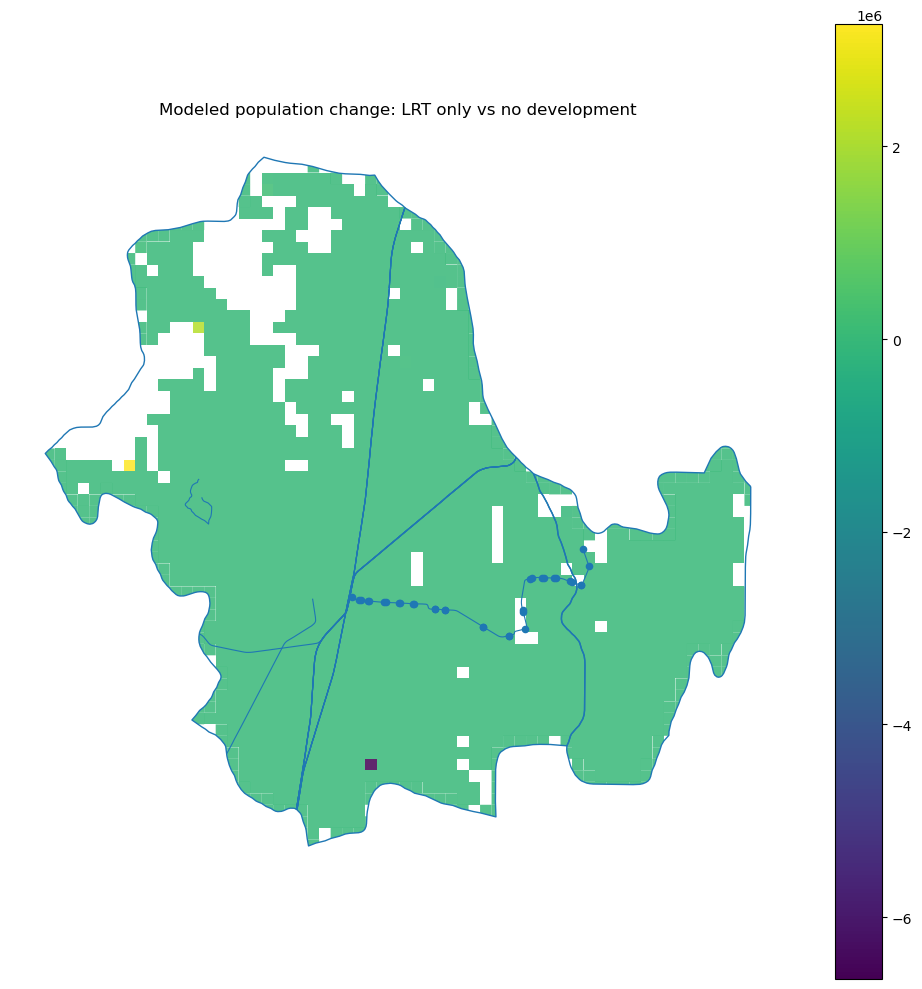

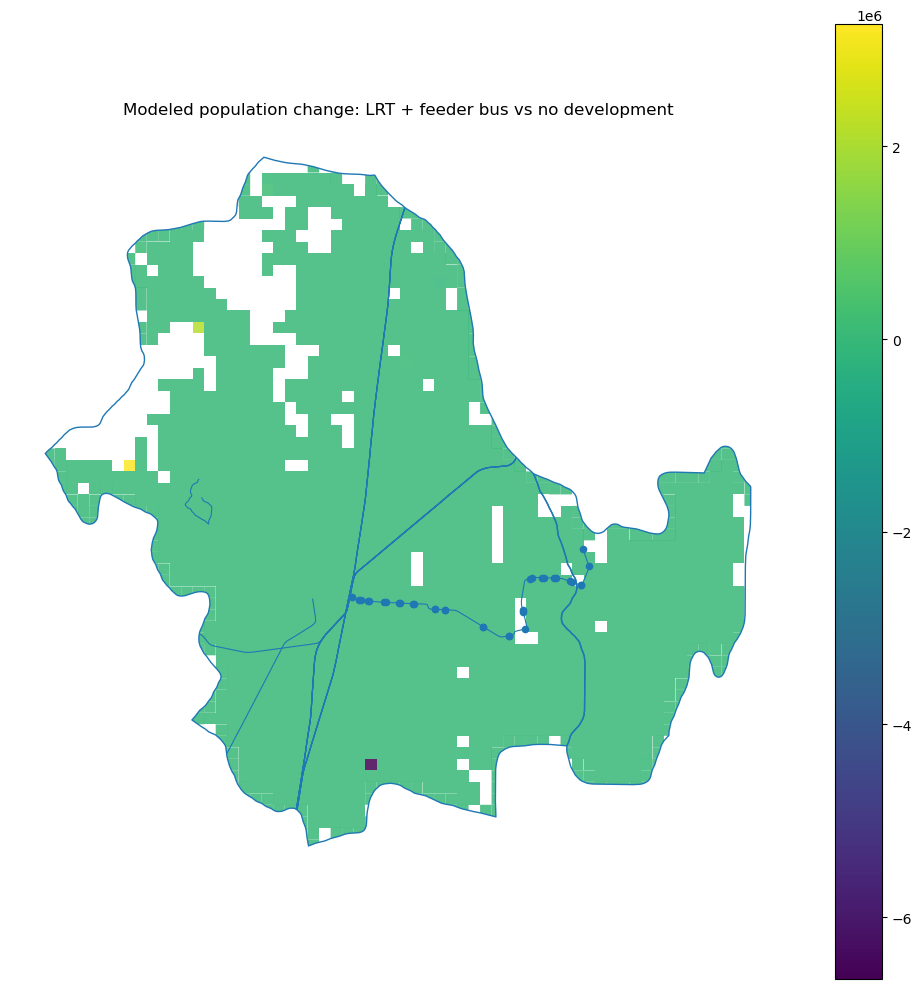

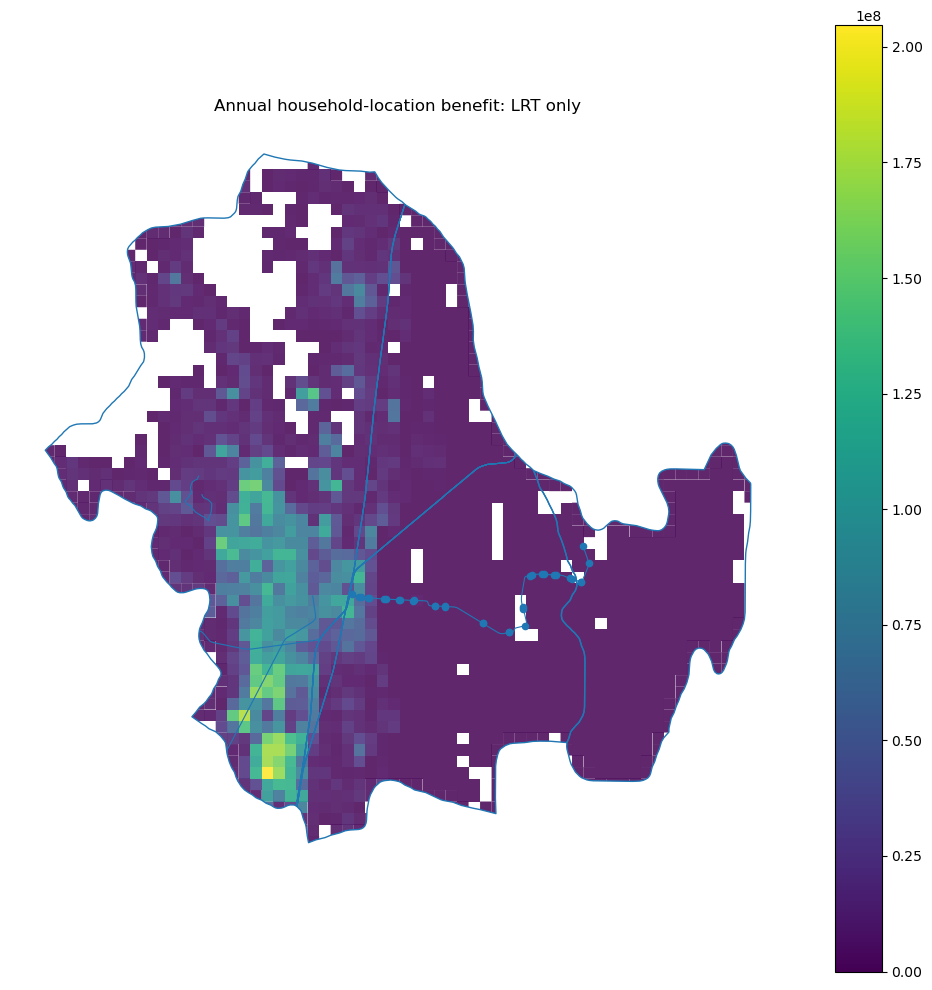

In [25]:
# Maps: population redistribution from Sasaki/Sato-style logit
for col, title, fname in [
    ("pop_chg_lrt_pct", "Modeled population change: LRT only vs no development", "map_pop_change_lrt_only.png"),
    ("pop_chg_fbs_pct", "Modeled population change: LRT + feeder bus vs no development", "map_pop_change_lrt_fbs.png"),
    ("benefit_lrt_yen", "Annual household-location benefit: LRT only", "map_annual_benefit_lrt.png"),
]:
    fig, ax = plt.subplots(figsize=(10, 10))
    zones.plot(ax=ax, column=col, legend=True, edgecolor="none", alpha=0.85)
    study_area.boundary.plot(ax=ax, linewidth=1)
    if rail_lines is not None and len(rail_lines):
        rail_lines.plot(ax=ax, linewidth=0.8)
    if feeder_stops is not None and len(feeder_stops):
        feeder_stops.plot(ax=ax, markersize=5, alpha=0.5)
    lrt_stops.plot(ax=ax, markersize=20)
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(FIG_DIR / fname, dpi=300, bbox_inches="tight")
    plt.show()

## 11. Cost-benefit comparison

This block outputs the same CBA comparison files as before, but adds the spatial EV result from the current shapefile layers.

,scenario,benefit_myen,cost_myen,npv_myen,bc_ratio
0,Paper: LRT only,60719.70000,59615.6,1104.10000,1.018520
1,Paper: LRT + feeder bus,69440.00000,63617.6,5822.40000,1.091522
2,Latest cost-only: LRT only,60719.70000,68400.0,-7680.30000,0.887715
3,Latest cost-only: LRT + feeder bus,69440.00000,72402.0,-2962.00000,0.959090
4,Shapefile EV: LRT only,556793.32057,68400.0,488393.32057,8.140253
5,Shapefile EV: LRT + feeder bus,556793.32057,72402.0,484391.32057,7.690303


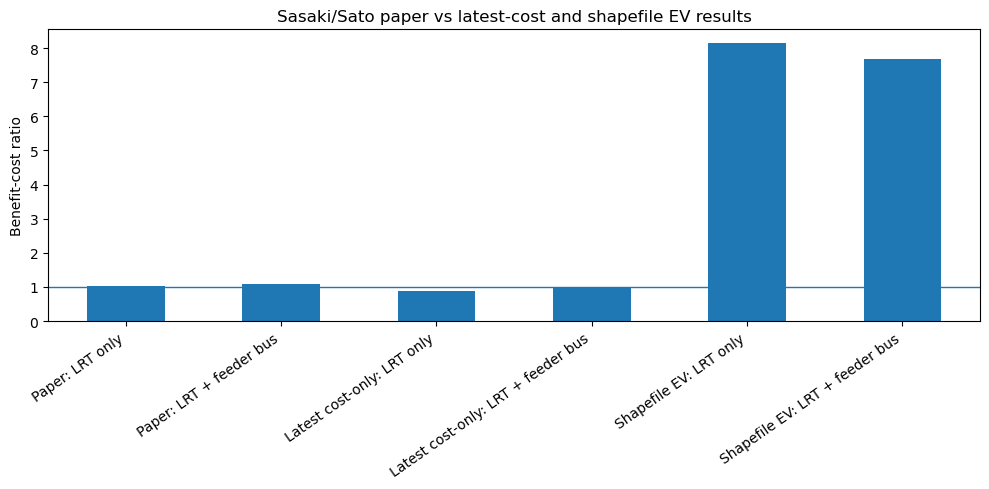

In [26]:
def pv_factor(years=ANALYSIS_YEARS, r=DISCOUNT_RATE):
    return sum(1 / ((1 + r) ** t) for t in range(1, years + 1))

pvf = pv_factor()

# Paper values, million yen
paper_lrt_benefit = 60_719.7
paper_lrt_cost = 59_615.6
paper_fbs_benefit = 69_440.0
paper_fbs_cost = 63_617.6

# Cost-only latest update from previous step
latest_lrt_cost = LATEST_LRT_COST_MILLION_YEN
latest_fbs_cost = LATEST_LRT_COST_MILLION_YEN + FEEDER_EXTRA_COST_MILLION_YEN

# Spatial EV result from this notebook: annual benefit yen -> PV million yen
spatial_lrt_benefit_m = zones["benefit_lrt_yen"].sum() * pvf / 1_000_000
spatial_fbs_benefit_m = zones["benefit_fbs_yen"].sum() * pvf / 1_000_000

cba = pd.DataFrame([
    {"scenario": "Paper: LRT only", "benefit_myen": paper_lrt_benefit, "cost_myen": paper_lrt_cost},
    {"scenario": "Paper: LRT + feeder bus", "benefit_myen": paper_fbs_benefit, "cost_myen": paper_fbs_cost},
    {"scenario": "Latest cost-only: LRT only", "benefit_myen": paper_lrt_benefit, "cost_myen": latest_lrt_cost},
    {"scenario": "Latest cost-only: LRT + feeder bus", "benefit_myen": paper_fbs_benefit, "cost_myen": latest_fbs_cost},
    {"scenario": "Shapefile EV: LRT only", "benefit_myen": spatial_lrt_benefit_m, "cost_myen": latest_lrt_cost},
    {"scenario": "Shapefile EV: LRT + feeder bus", "benefit_myen": spatial_fbs_benefit_m, "cost_myen": latest_fbs_cost},
])
cba["npv_myen"] = cba["benefit_myen"] - cba["cost_myen"]
cba["bc_ratio"] = cba["benefit_myen"] / cba["cost_myen"]
cba.to_csv(TABLE_DIR / "cba_comparison_sasaki_latest.csv", index=False)
display(cba)

fig, ax = plt.subplots(figsize=(10, 5))
cba.plot(x="scenario", y="bc_ratio", kind="bar", legend=False, ax=ax)
ax.axhline(1.0, linewidth=1)
ax.set_ylabel("Benefit-cost ratio")
ax.set_xlabel("")
ax.set_title("Sasaki/Sato paper vs latest-cost and shapefile EV results")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "bcr_comparison_sasaki_latest.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Export final model zones as shapefile and CSV

In [ ]:
# Keep a clean subset for shapefile export.
zone_export_cols = [
    "zone_id", "pop_total", "pop65", "households", "ZA_no_min", "ZA_lrt_min", "ZA_fbs_min",
    "ZB_no_min", "ZB_lrt_min", "ZC_grocery_min", "flood_depth_m", "land_price_yen_m2",
    "dist_lrt_m", "pop_chg_lrt", "pop_chg_fbs", "pop_chg_lrt_pct", "pop_chg_fbs_pct",
    "ev_hh_lrt_yen", "ev_hh_fbs_yen", "benefit_lrt_yen", "benefit_fbs_yen", "geometry"
]
zone_export = zones[[c for c in zone_export_cols if c in zones.columns]].copy()
zone_export.to_csv(TABLE_DIR / "sasaki_lrt_spatial_replication_table.csv", index=False)
export_shp(zone_export, "sasaki_lrt_spatial_replication_zones.shp")

print("Done. Main outputs:")
for p in sorted(TABLE_DIR.glob("*.csv")):
    print("TABLE ", p)
for p in sorted(FIG_DIR.glob("*.png")):
    print("FIGURE", p)
for p in sorted(SHP_DIR.glob("*.shp")):
    print("SHP   ", p)